# 02 — BDD100K Preparation for YOLO Training

**Goal:** Convert the official BDD100K dataset (70K train / 10K val) to YOLO format and cache it.

This notebook is **self-contained** — it handles everything in a single Colab session:

1. **Fast path:** Restore from cached `bdd100k_yolo_nb02.tar` on Drive (seconds)
2. **Slow path:** Extract original zips from Drive → convert to YOLO → create cached tar

**Input:** Original BDD100K zips on Drive (`EcoCAR/downloads/`)  
**Output:** YOLO dataset at `/content/bdd100k_yolo/` + cached tar on Drive for future sessions

## 1 — Install Dependencies

In [1]:
!pip install -q ultralytics opencv-python matplotlib Pillow pyyaml tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.5 MB/s eta 0:00:00


## 2 — Mount Drive & Configure Paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, yaml, glob

ECOCAR_ROOT = "/content/drive/MyDrive/EcoCAR"
DOWNLOADS   = os.path.join(ECOCAR_ROOT, "downloads")
DATASET_DIR = "/content/bdd100k_yolo"          # <-- all downstream notebooks use this path
TAR_DRIVE   = os.path.join(ECOCAR_ROOT, "datasets", "bdd100k_yolo_nb02.tar")

# Original BDD100K archives on Drive
IMAGES_ZIP = os.path.join(DOWNLOADS, "bdd100k_images_100k.zip")
LABELS_ZIP = os.path.join(DOWNLOADS, "bdd100k_labels.zip")

# Local raw extraction target (Colab SSD, fast I/O, does NOT persist)
BDD_RAW_DIR = "/content/bdd100k_raw"

# These will be discovered after extraction in cell 4
TRAIN_IMG_SRC  = None
VAL_IMG_SRC    = None
DET_TRAIN_JSON = None
DET_VAL_JSON   = None

print("Source archives on Drive:")
for name, path in [("Images zip", IMAGES_ZIP), ("Labels zip", LABELS_ZIP)]:
    if os.path.isfile(path):
        sz = os.path.getsize(path) / (1024**3)
        print(f"  {name}: {sz:.2f} GB")
    else:
        print(f"  {name}: NOT FOUND")

print(f"\nCached YOLO tar: {'EXISTS' if os.path.isfile(TAR_DRIVE) else 'not yet created'}")
print(f"Output dir:      {DATASET_DIR}")

Source archives on Drive:
  Images zip: 5.28 GB
  Labels zip: 0.18 GB

Cached YOLO tar: EXISTS
Output dir:      /content/bdd100k_yolo


## 3 — Clone/Upload Source Utilities

In [4]:
!git clone https://github.com/ChenSiyun1234/EcoCAR-Perception-Pipeline-YOLO26-BDD100K.git /content/repo 2>/dev/null || true

import sys
sys.path.insert(0, "/content/repo")
sys.path.insert(0, "/content/repo/src")

try:
    from src.dataset_utils import (
        convert_bdd100k_to_yolo,
        aggregate_per_frame_jsons,
        create_dataset_yaml,
        verify_dataset_structure,
        link_or_copy_images,
        find_expected_images,
        print_class_distribution,
        BDD_CLASSES, CLASS_TO_ID,
    )
    print("Loaded utilities from src/dataset_utils.py")
except ImportError:
    print("Could not import dataset_utils. Using inline fallback.")
    # Inline fallback omitted for brevity — ensure src/ is available.

Loaded utilities from src/dataset_utils.py


## 4 — Restore or Extract

**Priority order:**
1. Dataset already on local SSD → skip everything
2. Cached `bdd100k_yolo_nb02.tar` on Drive → restore (fast, ~2 min)
3. No cache → extract original zips to local SSD, then convert (slow, ~15 min)

In [5]:
import tarfile, zipfile, shutil

SKIP_CONVERSION = False

# Drive path for persisting aggregated label JSONs (used by NB07)
AGG_DRIVE_DIR = os.path.join(ECOCAR_ROOT, "datasets", "bdd100k_labels_aggregated")

# ── Priority 1: already on local SSD ────────────────────────────────
if os.path.isdir(os.path.join(DATASET_DIR, "images", "val")):
    n_val = len(os.listdir(os.path.join(DATASET_DIR, "images", "val")))
    if n_val > 1000:
        print(f"Dataset already present at {DATASET_DIR} ({n_val} val images). Skipping.")
        SKIP_CONVERSION = True

# ── Priority 2: restore from cached tar on Drive ────────────────────
if not SKIP_CONVERSION and os.path.isfile(TAR_DRIVE):
    sz = os.path.getsize(TAR_DRIVE) / (1024**3)
    print(f"Found cached tar on Drive ({sz:.2f} GB). Restoring...")
    os.makedirs(DATASET_DIR, exist_ok=True)
    with tarfile.open(TAR_DRIVE, "r") as tar:
        tar.extractall(DATASET_DIR)
    print(f"Restored to {DATASET_DIR}")
    SKIP_CONVERSION = True

# ── Priority 3: extract from original zips ──────────────────────────
if not SKIP_CONVERSION:
    print("No cached tar. Extracting from original zips on Drive...\n")
    os.makedirs(BDD_RAW_DIR, exist_ok=True)

    for label, zip_path in [("Images", IMAGES_ZIP), ("Labels", LABELS_ZIP)]:
        assert os.path.isfile(zip_path), f"{label} zip not found: {zip_path}"
        # Quick check if already extracted in this session
        already = False
        with zipfile.ZipFile(zip_path, 'r') as zf:
            for info in zf.infolist():
                if not info.is_dir():
                    if os.path.isfile(os.path.join(BDD_RAW_DIR, info.filename)):
                        already = True
                    break
        if already:
            print(f"  {label}: already extracted. Skipping.")
            continue
        sz = os.path.getsize(zip_path) / (1024**3)
        print(f"  Extracting {label} ({sz:.2f} GB)...")
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(BDD_RAW_DIR)
        print(f"  Done.")

    # ── Show what we got ─────────────────────────────────────────────
    print(f"\nExtracted structure under {BDD_RAW_DIR}/:")
    for root, dirs, files in os.walk(BDD_RAW_DIR):
        depth = root.replace(BDD_RAW_DIR, '').count(os.sep)
        if depth > 3:
            dirs.clear()
            continue
        indent = '  ' * (depth + 1)
        rel = os.path.relpath(root, BDD_RAW_DIR)
        if rel != '.':
            print(f"{indent}{os.path.basename(root)}/  ({len(files)} files, {len(dirs)} subdirs)")

    # ── Auto-detect image directories ────────────────────────────────
    candidate_patterns = [
        os.path.join(BDD_RAW_DIR, "bdd100k", "images", "100k", "{split}"),
        os.path.join(BDD_RAW_DIR, "images", "100k", "{split}"),
        os.path.join(BDD_RAW_DIR, "100k", "{split}"),
        os.path.join(BDD_RAW_DIR, "bdd100k", "images", "{split}"),
        os.path.join(BDD_RAW_DIR, "images", "{split}"),
        os.path.join(BDD_RAW_DIR, "{split}"),
    ]
    for pattern in candidate_patterns:
        train_cand = pattern.format(split="train")
        if os.path.isdir(train_cand):
            sample = [f for f in os.listdir(train_cand)[:10]
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if sample:
                TRAIN_IMG_SRC = train_cand
                val_cand = pattern.format(split="val")
                VAL_IMG_SRC = val_cand if os.path.isdir(val_cand) else None
                break

    assert TRAIN_IMG_SRC, (
        f"Could not find train images under {BDD_RAW_DIR}/\n"
        f"Searched patterns:\n" +
        "\n".join(f"  {p.format(split='train')}" for p in candidate_patterns)
    )
    n_train = sum(1 for f in os.listdir(TRAIN_IMG_SRC) if f.lower().endswith(('.jpg','.png')))
    print(f"\nTrain images: {TRAIN_IMG_SRC}  ({n_train:,})")
    if VAL_IMG_SRC:
        n_val = sum(1 for f in os.listdir(VAL_IMG_SRC) if f.lower().endswith(('.jpg','.png')))
        print(f"Val images:   {VAL_IMG_SRC}  ({n_val:,})")

    # ── Auto-detect label JSONs ──────────────────────────────────────
    all_jsons = sorted(glob.glob(os.path.join(BDD_RAW_DIR, "**", "*.json"), recursive=True))
    print(f"\nAll JSON files found ({len(all_jsons)}):")
    for i, jf in enumerate(all_jsons):
        if i >= 20:
            print(f"  ... and {len(all_jsons) - 20} more JSON files")
            break
        sz = os.path.getsize(jf) / (1024**2)
        print(f"  {os.path.relpath(jf, BDD_RAW_DIR)}  ({sz:.1f} MB)")

    # Strategy 1: Search by filename pattern (broad matching)
    for jf in all_jsons:
        bn = os.path.basename(jf).lower()
        if not DET_TRAIN_JSON and 'train' in bn and ('det' in bn or 'label' in bn):
            DET_TRAIN_JSON = jf
        if not DET_VAL_JSON and 'val' in bn and ('det' in bn or 'label' in bn):
            DET_VAL_JSON = jf

    # Strategy 2: Fallback — try known directory structures
    if not DET_TRAIN_JSON or not DET_VAL_JSON:
        known_paths = [
            ("bdd100k/labels/det_20/det_train.json", "bdd100k/labels/det_20/det_val.json"),
            ("labels/det_20/det_train.json", "labels/det_20/det_val.json"),
            ("bdd100k/labels/det_train.json", "bdd100k/labels/det_val.json"),
            ("labels/det_train.json", "labels/det_val.json"),
            ("det_train.json", "det_val.json"),
        ]
        for train_rel, val_rel in known_paths:
            t = os.path.join(BDD_RAW_DIR, train_rel)
            v = os.path.join(BDD_RAW_DIR, val_rel)
            if not DET_TRAIN_JSON and os.path.isfile(t):
                DET_TRAIN_JSON = t
            if not DET_VAL_JSON and os.path.isfile(v):
                DET_VAL_JSON = v

    # Strategy 3: Any large JSON with "train"/"val" in name
    if not DET_TRAIN_JSON or not DET_VAL_JSON:
        for jf in all_jsons:
            bn = os.path.basename(jf).lower()
            sz_mb = os.path.getsize(jf) / (1024**2)
            if sz_mb < 1.0:
                continue
            if not DET_TRAIN_JSON and 'train' in bn:
                DET_TRAIN_JSON = jf
            if not DET_VAL_JSON and 'val' in bn:
                DET_VAL_JSON = jf

    # Strategy 4: Per-frame Scalabel JSONs — aggregate into single file
    if not DET_TRAIN_JSON or not DET_VAL_JSON:
        print("\nStrategies 1-3 failed. Checking for per-frame Scalabel JSONs...")

        per_frame_dirs = {}
        for jf in all_jsons:
            parent = os.path.dirname(jf)
            per_frame_dirs[parent] = per_frame_dirs.get(parent, 0) + 1

        for d, count in sorted(per_frame_dirs.items(), key=lambda x: -x[1]):
            if count < 100:
                continue
            bn = os.path.basename(d).lower()
            full_lower = d.lower()
            print(f"  Found {count:,} JSONs in: {os.path.relpath(d, BDD_RAW_DIR)}")

            if not DET_TRAIN_JSON and ('train' in bn or '/train' in full_lower):
                agg_path = os.path.join(BDD_RAW_DIR, "det_train_aggregated.json")
                print(f"  Aggregating {count:,} train per-frame JSONs...")
                n = aggregate_per_frame_jsons(d, agg_path)
                if n > 0:
                    DET_TRAIN_JSON = agg_path

            if not DET_VAL_JSON and ('val' in bn or '/val' in full_lower):
                agg_path = os.path.join(BDD_RAW_DIR, "det_val_aggregated.json")
                print(f"  Aggregating {count:,} val per-frame JSONs...")
                n = aggregate_per_frame_jsons(d, agg_path)
                if n > 0:
                    DET_VAL_JSON = agg_path

    # ── Save aggregated JSONs to Drive for other notebooks (NB07) ────
    if DET_TRAIN_JSON and DET_VAL_JSON:
        os.makedirs(AGG_DRIVE_DIR, exist_ok=True)
        for src, name in [(DET_TRAIN_JSON, "train.json"), (DET_VAL_JSON, "val.json")]:
            dst = os.path.join(AGG_DRIVE_DIR, name)
            if not os.path.isfile(dst):
                print(f"  Saving {name} to Drive for downstream notebooks...")
                shutil.copy2(src, dst)
                print(f"  Saved: {dst}")
            else:
                print(f"  {name} already on Drive: {dst}")

    print(f"\nDetection labels:")
    print(f"  Train: {DET_TRAIN_JSON or 'NOT FOUND'}")
    print(f"  Val:   {DET_VAL_JSON or 'NOT FOUND'}")

    if not DET_TRAIN_JSON or not DET_VAL_JSON:
        print("\n" + "!" * 60)
        print("WARNING: Could not auto-detect detection label JSONs.")
        print("Check the JSON files listed above and set paths manually:")
        print("  DET_TRAIN_JSON = '/content/bdd100k_raw/...'")
        print("  DET_VAL_JSON   = '/content/bdd100k_raw/...'")
        print("!" * 60)
    else:
        print("\nReady for conversion.")

Found cached tar on Drive (4.49 GB). Restoring...


/tmp/ipykernel_3772/3392059911.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATASET_DIR)


Restored to /content/bdd100k_yolo


## 5 — Convert Detection Labels to YOLO Format

In [6]:
if not SKIP_CONVERSION:
    assert DET_TRAIN_JSON and os.path.isfile(DET_TRAIN_JSON), (
        f"Train labels not found: {DET_TRAIN_JSON}\n"
        "Go back to cell 9 output — check the JSON list and set DET_TRAIN_JSON manually."
    )
    assert DET_VAL_JSON and os.path.isfile(DET_VAL_JSON), (
        f"Val labels not found: {DET_VAL_JSON}\n"
        "Go back to cell 9 output — check the JSON list and set DET_VAL_JSON manually."
    )

    TRAIN_LABEL_DIR = os.path.join(DATASET_DIR, "labels", "train")
    VAL_LABEL_DIR   = os.path.join(DATASET_DIR, "labels", "val")

    print("=" * 50)
    print(" Converting TRAIN labels")
    print("=" * 50)
    train_counts = convert_bdd100k_to_yolo(DET_TRAIN_JSON, TRAIN_LABEL_DIR)
    print_class_distribution(train_counts)

    print("\n" + "=" * 50)
    print(" Converting VAL labels")
    print("=" * 50)
    val_counts = convert_bdd100k_to_yolo(DET_VAL_JSON, VAL_LABEL_DIR)
    print_class_distribution(val_counts)

    n_train = len([f for f in os.listdir(TRAIN_LABEL_DIR) if f.endswith('.txt')])
    n_val   = len([f for f in os.listdir(VAL_LABEL_DIR)   if f.endswith('.txt')])
    print(f"\nLabel files written: {n_train:,} train / {n_val:,} val")
else:
    print("Skipped (dataset already restored).")

Skipped (dataset already restored).


## 6 — Link Images

Symlink images from the raw extraction directory into the YOLO dataset layout.
Symlinks are fast and save ~6 GB of disk on Colab.

In [7]:
if not SKIP_CONVERSION:
    TRAIN_IMG_DST = os.path.join(DATASET_DIR, "images", "train")
    VAL_IMG_DST   = os.path.join(DATASET_DIR, "images", "val")

    TRAIN_LABEL_DIR = os.path.join(DATASET_DIR, "labels", "train")
    VAL_LABEL_DIR   = os.path.join(DATASET_DIR, "labels", "val")

    print("Linking TRAIN images...")
    train_stems = [os.path.splitext(f)[0] for f in os.listdir(TRAIN_LABEL_DIR) if f.endswith('.txt')]
    train_imgs = [s + ".jpg" for s in train_stems]
    n_train = link_or_copy_images(TRAIN_IMG_SRC, TRAIN_IMG_DST,
                                  use_symlinks=True, image_list=train_imgs)
    print(f"  Linked {n_train:,} train images")

    print("\nLinking VAL images...")
    val_stems = [os.path.splitext(f)[0] for f in os.listdir(VAL_LABEL_DIR) if f.endswith('.txt')]
    val_imgs = [s + ".jpg" for s in val_stems]
    n_val = link_or_copy_images(VAL_IMG_SRC, VAL_IMG_DST,
                                use_symlinks=True, image_list=val_imgs)
    print(f"  Linked {n_val:,} val images")
else:
    print("Skipped (dataset already restored).")

Skipped (dataset already restored).


## 7 — Generate Dataset YAML

In [8]:
import shutil

DATASET_YAML = os.path.join(DATASET_DIR, "bdd100k_yolo.yaml")

if not SKIP_CONVERSION or not os.path.isfile(DATASET_YAML):
    create_dataset_yaml(DATASET_DIR, DATASET_YAML)

    # Backup copy to Drive
    backup_dir = os.path.join(ECOCAR_ROOT, "datasets")
    os.makedirs(backup_dir, exist_ok=True)
    shutil.copy2(DATASET_YAML, os.path.join(backup_dir, "bdd100k_yolo.yaml"))
    print(f"Backup saved to {backup_dir}/bdd100k_yolo.yaml")
else:
    print(f"YAML already exists: {DATASET_YAML}")

# Show contents
with open(DATASET_YAML) as f:
    print(f.read())

YAML already exists: /content/bdd100k_yolo/bdd100k_yolo.yaml
path: /content/bdd100k_yolo
train: images/train
val: images/val
nc: 10
names:
  0: person
  1: rider
  2: car
  3: truck
  4: bus
  5: train
  6: motorcycle
  7: bicycle
  8: traffic light
  9: traffic sign



## 8 — Verify Dataset Structure

In [9]:
print("=" * 50)
print(" DATASET VERIFICATION")
print("=" * 50)

verify_dataset_structure(DATASET_DIR)

# Cross-check: labels vs images
for split in ["train", "val"]:
    lbl_dir = os.path.join(DATASET_DIR, "labels", split)
    img_dir = os.path.join(DATASET_DIR, "images", split)
    n_lbl = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')])
    n_img = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    match = "OK" if n_lbl == n_img else f"MISMATCH (labels={n_lbl}, images={n_img})"
    print(f"  {split}: {n_img:,} images, {n_lbl:,} labels -- {match}")

 DATASET VERIFICATION
✅ images/train: 70000 files
✅ images/val: 10000 files
✅ labels/train: 70000 files
✅ labels/val: 10000 files
  train: 70,000 images, 70,000 labels -- OK
  val: 10,000 images, 10,000 labels -- OK


## 9 — Create Tar Archive for Fast Colab Restore

Pack the YOLO dataset into `bdd100k_yolo_nb02.tar` and upload to Drive.
Future sessions can skip steps 5-8 by restoring from this tar.

**Important:** Uses `-h` flag to dereference symlinks (includes actual image data).
This makes the tar self-contained (~6-7 GB) but avoids needing the raw extraction.

In [10]:
import subprocess, time

TAR_LOCAL = "/content/bdd100k_yolo_nb02.tar"

if SKIP_CONVERSION:
    print("Dataset was restored from cache. Skipping tar creation.")
elif os.path.isfile(TAR_DRIVE):
    print(f"Tar already exists on Drive: {TAR_DRIVE}")
    print(f"  Size: {os.path.getsize(TAR_DRIVE)/(1024**3):.2f} GB")
else:
    print("Creating tar archive (this may take 10-20 minutes)...")
    t0 = time.time()
    result = subprocess.run(
        ["tar", "-chf", TAR_LOCAL,
         "-C", DATASET_DIR,
         "images", "labels", "bdd100k_yolo.yaml"],
        capture_output=True, text=True
    )
    elapsed = time.time() - t0
    if result.returncode != 0:
        print(f"tar failed: {result.stderr}")
    else:
        sz = os.path.getsize(TAR_LOCAL) / (1024**3)
        print(f"Tar created: {sz:.2f} GB in {elapsed:.0f}s")

Dataset was restored from cache. Skipping tar creation.


In [11]:
# Upload tar to Drive
if os.path.isfile(TAR_LOCAL) and not os.path.isfile(TAR_DRIVE):
    os.makedirs(os.path.dirname(TAR_DRIVE), exist_ok=True)
    print(f"Copying tar to Drive... (this may take a few minutes)")
    shutil.copy2(TAR_LOCAL, TAR_DRIVE)
    print(f"Uploaded: {TAR_DRIVE}")
    print(f"  Size: {os.path.getsize(TAR_DRIVE)/(1024**3):.2f} GB")
    # Clean up local tar to free SSD space
    os.remove(TAR_LOCAL)
    print(f"Cleaned up local tar.")
elif os.path.isfile(TAR_DRIVE):
    print(f"Tar already on Drive: {TAR_DRIVE}")
else:
    print("No tar to upload (dataset was restored from cache).")

Tar already on Drive: /content/drive/MyDrive/EcoCAR/datasets/bdd100k_yolo_nb02.tar


## 10 — Visualise Sample Annotations

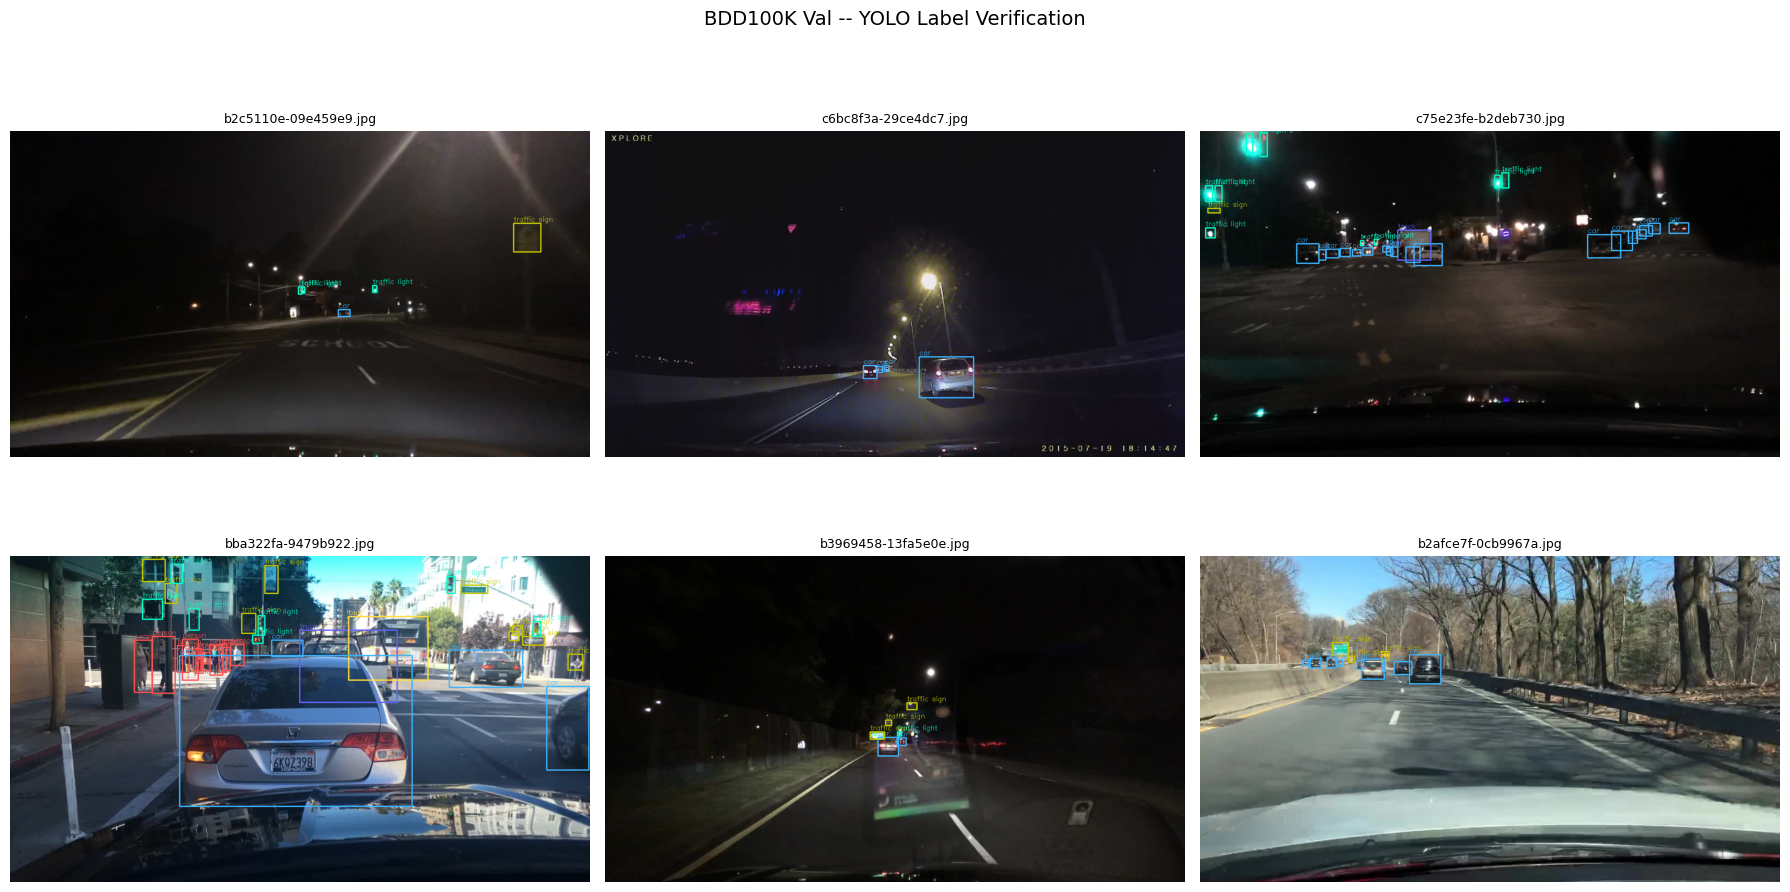

In [12]:
import cv2, matplotlib.pyplot as plt, random
import numpy as np

val_img_dir = os.path.join(DATASET_DIR, "images", "val")
val_lbl_dir = os.path.join(DATASET_DIR, "labels", "val")

COLORS = [
    (255,80,80), (255,160,60), (60,180,255), (100,100,255),
    (255,220,60), (180,100,255), (100,255,100), (255,100,200),
    (0,255,200), (200,200,0),
]

sample_labels = [f for f in os.listdir(val_lbl_dir) if f.endswith('.txt')]
random.seed(42)
random.shuffle(sample_labels)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

shown = 0
for lbl_file in sample_labels:
    if shown >= 6:
        break
    img_file = lbl_file.replace('.txt', '.jpg')
    img_path = os.path.join(val_img_dir, img_file)
    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    with open(os.path.join(val_lbl_dir, lbl_file)) as f:
        lines = f.read().strip().split('\n')

    for line in lines:
        if not line.strip():
            continue
        parts = line.split()
        cls_id = int(parts[0])
        xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        color = COLORS[cls_id % len(COLORS)]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, BDD_CLASSES[cls_id], (x1, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    axes[shown].imshow(img)
    axes[shown].set_title(img_file, fontsize=9)
    axes[shown].axis('off')
    shown += 1

plt.suptitle("BDD100K Val -- YOLO Label Verification", fontsize=14)
plt.tight_layout()
plt.show()

## 11 — Summary

In [13]:
print("\n" + "=" * 60)
print(" NB02 COMPLETE -- BDD100K YOLO Dataset")
print("=" * 60)

for split in ["train", "val"]:
    img_dir = os.path.join(DATASET_DIR, "images", split)
    lbl_dir = os.path.join(DATASET_DIR, "labels", split)
    n_img = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.png'))]) if os.path.isdir(img_dir) else 0
    n_lbl = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')]) if os.path.isdir(lbl_dir) else 0
    print(f"  {split:>5}: {n_img:>6,} images, {n_lbl:>6,} labels")

print(f"\n  Dataset YAML:  {DATASET_DIR}/bdd100k_yolo.yaml")
print(f"  Cached tar:    {TAR_DRIVE}")

if os.path.isfile(TAR_DRIVE):
    print(f"  Tar size:      {os.path.getsize(TAR_DRIVE)/(1024**3):.2f} GB")

print("=" * 60)
print("\nNext: Run 03_bdd100k_training.ipynb to fine-tune YOLO26 on BDD100K.")


 NB02 COMPLETE -- BDD100K YOLO Dataset
  train: 70,000 images, 70,000 labels
    val: 10,000 images, 10,000 labels

  Dataset YAML:  /content/bdd100k_yolo/bdd100k_yolo.yaml
  Cached tar:    /content/drive/MyDrive/EcoCAR/datasets/bdd100k_yolo_nb02.tar
  Tar size:      4.49 GB

Next: Run 03_bdd100k_training.ipynb to fine-tune YOLO26 on BDD100K.


---

### How it works across Colab sessions

Each Colab session has its own local SSD — data does NOT persist between sessions.

**First run (slow path, ~15 min):**
1. Extracts `bdd100k_images_100k.zip` + `bdd100k_labels.zip` from Drive to local SSD
2. Converts labels to YOLO format, symlinks images
3. Creates `bdd100k_yolo_nb02.tar` and uploads to Drive

**Subsequent runs (fast path, ~2 min):**
1. Detects cached `bdd100k_yolo_nb02.tar` on Drive
2. Restores directly to `/content/bdd100k_yolo/`
3. Skips all conversion steps

### Downstream Path Contract

All subsequent notebooks (03-09) expect:

```
DATASET_DIR = "/content/bdd100k_yolo"

/content/bdd100k_yolo/
  images/train/    (~70K .jpg)
  images/val/      (~10K .jpg)
  labels/train/    (~70K .txt)
  labels/val/      (~10K .txt)
  bdd100k_yolo.yaml
```